In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn pillow

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached pillow-12.1.1-cp310-cp310-win_amd64.whl.metadata (9.0 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp310-cp310-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using

In [4]:
!pip install pandas matplotlib seaborn

In [6]:
import sys
!{sys.executable} -m pip install pyyaml pandas matplotlib seaborn

'c:\Users\USER\Downloads\Clean' is not recognized as an internal or external command,
operable program or batch file.
The system cannot find the path specified.


تم العثور على 31 كلاس بنجاح.

--- تقرير توزيع الكلاسات ---
 Class_ID           Class_Name  Instance_Count
        2              Filling           33313
       11       impacted tooth           18863
        9 Root Canal Treatment           13127
        1                Crown            8008
        0               Caries            7350
        7    Periapical lesion            3596
       13            Bone Loss            2646
        6        Missing teeth            2626
       10           Root Piece            1910
        3              Implant            1373
        5     Mandibular Canal             506
       12      maxillary sinus             384
       25          post - core             277
       27                 wire             208
        8        Retained root             133
       23 orthodontic brackets             120
       30        Primary teeth             118
       22           metal band              64
       19            attrition              44
 

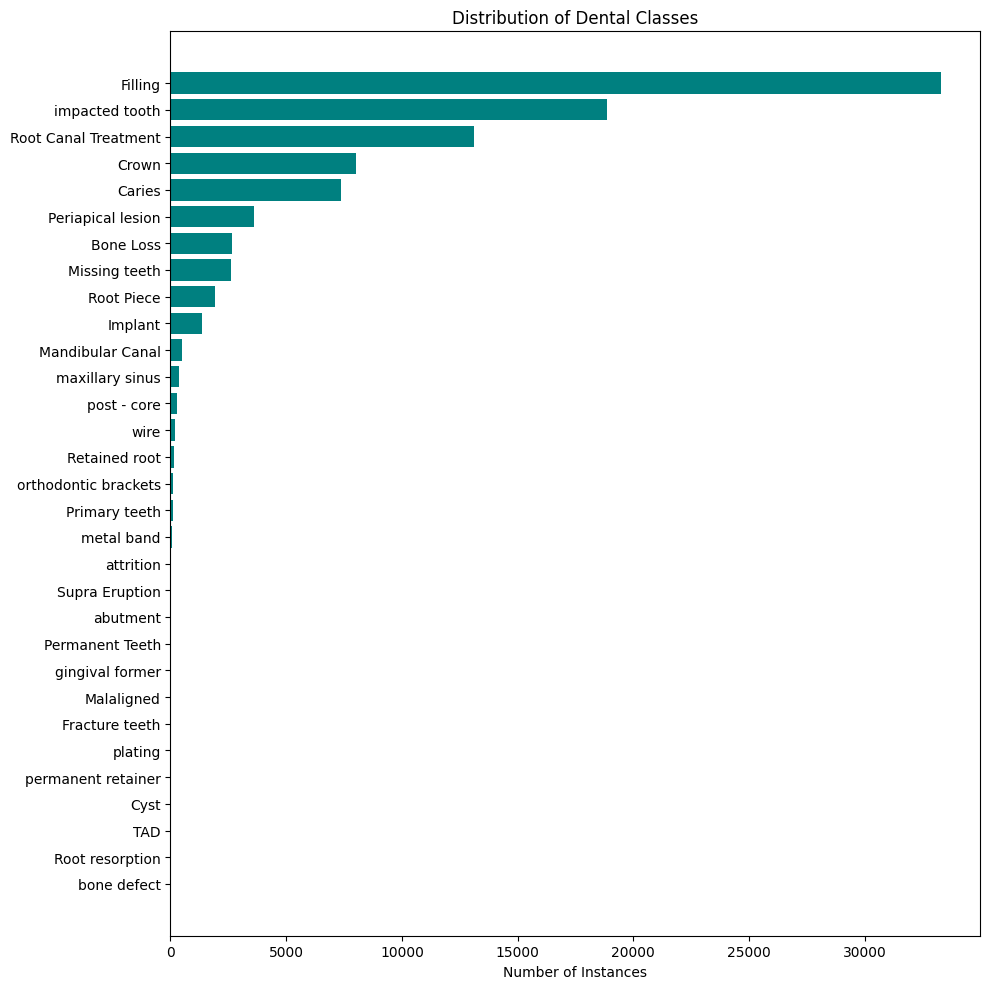

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import yaml

# 1. تحديد المسارات الكاملة (استخدمنا r قبل النص لتفادي أخطاء المسارات في ويندوز)
yaml_path = r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO\data.yaml"
labels_path = r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO\train\labels"

# 2. قراءة أسماء الكلاسات من ملف data.yaml
try:
    with open(yaml_path, 'r', encoding='utf-8') as f:
        data_meta = yaml.safe_load(f)
        class_names = data_meta['names']
        print(f"تم العثور على {len(class_names)} كلاس بنجاح.")
except Exception as e:
    print(f"خطأ في قراءة ملف yaml: {e}")

# 3. جرد جميع الحالات (Instances) من ملفات الـ txt
stats = {i: 0 for i in range(len(class_names))}

if os.path.exists(labels_path):
    for label_file in os.listdir(labels_path):
        if label_file.endswith('.txt'):
            with open(os.path.join(labels_path, label_file), 'r') as f:
                for line in f:
                    parts = line.split()
                    if parts:
                        class_id = int(parts[0])
                        if class_id in stats:
                            stats[class_id] += 1
else:
    print("المسار الخاص بمجلد labels غير صحيح، تأكد من وجوده.")

# 4. تحويل النتائج لجدول
df_stats = pd.DataFrame({
    'Class_ID': list(stats.keys()),
    'Class_Name': [class_names[i] for i in stats.keys()],
    'Instance_Count': list(stats.values())
}).sort_values(by='Instance_Count', ascending=False)

# 5. عرض النتائج
print("\n--- تقرير توزيع الكلاسات ---")
print(df_stats.to_string(index=False))

# 6. رسم بياني
plt.figure(figsize=(10, 10))
plt.barh(df_stats['Class_Name'], df_stats['Instance_Count'], color='teal')
plt.xlabel('Number of Instances')
plt.title('Distribution of Dental Classes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
import os

# 1. تعريف المسارات (تأكد من صحتها في جهازك)
base_path = r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO"
folders = ['train', 'valid', 'test']

# 2. تحديد الخريطة الجديدة (Old ID : New ID)
# 11 -> 0 (Impacted), 0 -> 1 (Caries), 7 -> 2 (Periapical), Rest -> 3 (Other)
mapping = {11: 0, 0: 1, 7: 2}

def process_labels(folder_name):
    label_dir = os.path.join(base_path, folder_name, 'labels')
    if not os.path.exists(label_dir):
        return

    for filename in os.listdir(label_dir):
        if filename.endswith('.txt'):
            file_path = os.path.join(label_dir, filename)
            new_lines = []
            
            with open(file_path, 'r') as f:
                for line in f:
                    parts = line.split()
                    if not parts: continue
                    
                    old_cls = int(parts[0])
                    # إذا كان الكلاس من الـ 3 المختارين خذ رقمه الجديد، وإلا اجعله 3 (Other)
                    new_cls = mapping.get(old_cls, 3)
                    
                    # إعادة بناء السطر بالرقم الجديد
                    new_lines.append(f"{new_cls} " + " ".join(parts[1:]) + "\n")
            
            # حفظ التعديلات في نفس الملف
            with open(file_path, 'w') as f:
                f.writelines(new_lines)

# تشغيل عملية التحويل
for folder in folders:
    process_labels(folder)
    print(f"تم الانتهاء من تعديل مجلد: {folder}")

print("\nتم تحويل الداتاسيت إلى 4 كلاسات بنجاح!")

تم الانتهاء من تعديل مجلد: train
تم الانتهاء من تعديل مجلد: valid
تم الانتهاء من تعديل مجلد: test

تم تحويل الداتاسيت إلى 4 كلاسات بنجاح!


In [9]:
import os
import random

# 1. المسار الأساسي
base_path = r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO"
folders = ['train', 'valid', 'test']

# 2. إعدادات الموازنة لكل مجلد (يمكنك تعديل الأرقام حسب رغبتك)
# الهدف: جعل كلاس Other متقارب في العدد مع الكلاسات الأساسية في كل مجلد
target_counts = {
    'train': 15000, 
    'valid': 2000,
    'test': 2000
}

TARGET_CLASS = 3  # كلاس Other

for folder in folders:
    label_dir = os.path.join(base_path, folder, 'labels')
    image_dir = os.path.join(base_path, folder, 'images')
    
    if not os.path.exists(label_dir):
        continue

    other_only_files = []
    important_files = []

    # 3. جرد الملفات وتصنيفها في المجلد الحالي
    for filename in os.listdir(label_dir):
        if filename.endswith('.txt'):
            file_path = os.path.join(label_dir, filename)
            with open(file_path, 'r') as f:
                lines = f.readlines()
                classes = [int(line.split()[0]) for line in lines if line.strip()]
                
                if classes and all(cls == TARGET_CLASS for cls in classes):
                    other_only_files.append(filename)
                else:
                    important_files.append(filename)

    print(f"\n--- مجلد {folder} ---")
    print(f"صور 'Other' فقط: {len(other_only_files)}")
    print(f"الصور المهمة: {len(important_files)}")

    # 4. الموازنة
    max_samples = target_counts[folder]
    if len(other_only_files) > max_samples:
        files_to_keep = random.sample(other_only_files, max_samples)
        files_to_delete = set(other_only_files) - set(files_to_keep)
        
        print(f"جاري حذف {len(files_to_delete)} ملف زائد من {folder}...")
        
        for filename in files_to_delete:
            # حذف ملف الليبل
            os.remove(os.path.join(label_dir, filename))
            
            # حذف الصورة المقابلة (يدعم .jpg و .png و .jpeg)
            found_img = False
            for ext in ['.jpg', '.png', '.jpeg', '.JPG']:
                img_path = os.path.join(image_dir, filename.replace('.txt', ext))
                if os.path.exists(img_path):
                    os.remove(img_path)
                    found_img = True
                    break
    else:
        print(f"مجلد {folder} متزن بالفعل أو عدد Other فيه أقل من الحد.")

print("\nتمت موازنة كامل الداتاسيت بنجاح!")


--- مجلد train ---
صور 'Other' فقط: 486
الصور المهمة: 8995
مجلد train متزن بالفعل أو عدد Other فيه أقل من الحد.

--- مجلد valid ---
صور 'Other' فقط: 117
الصور المهمة: 2754
مجلد valid متزن بالفعل أو عدد Other فيه أقل من الحد.

--- مجلد test ---
صور 'Other' فقط: 63
الصور المهمة: 1517
مجلد test متزن بالفعل أو عدد Other فيه أقل من الحد.

تمت موازنة كامل الداتاسيت بنجاح!


In [20]:
import os
import pandas as pd

base_path = r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO"
folders = ['train', 'valid', 'test']
class_map = {0: 'Impacted', 1: 'Caries', 2: 'Periapical', 3: 'Other'}

for folder in folders:
    lbl_path = os.path.join(base_path, folder, 'labels')
    img_path = os.path.join(base_path, folder, 'images')
    
    if not os.path.exists(lbl_path): continue
    
    stats = {0:0, 1:0, 2:0, 3:0}
    img_count = len([f for f in os.listdir(img_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    lbl_count = 0
    
    for file in os.listdir(lbl_path):
        if file.endswith('.txt'):
            lbl_count += 1
            with open(os.path.join(lbl_path, file), 'r') as f:
                for line in f:
                    parts = line.split()
                    if parts:
                        cls = int(parts[0])
                        stats[cls] = stats.get(cls, 0) + 1
    
    print(f"\n--- إحصائيات مجلد {folder} ---")
    print(f"عدد الصور: {img_count} | عدد ملفات الليبل: {lbl_count}")
    for cls_id, count in stats.items():
        print(f"  - {class_map[cls_id]}: {count} instance")


--- إحصائيات مجلد train ---
عدد الصور: 3526 | عدد ملفات الليبل: 3526
  - Impacted: 5113 instance
  - Caries: 7350 instance
  - Periapical: 3596 instance
  - Other: 33478 instance

--- إحصائيات مجلد valid ---
عدد الصور: 2747 | عدد ملفات الليبل: 2747
  - Impacted: 5859 instance
  - Caries: 2180 instance
  - Periapical: 1132 instance
  - Other: 16980 instance

--- إحصائيات مجلد test ---
عدد الصور: 1517 | عدد ملفات الليبل: 1517
  - Impacted: 3256 instance
  - Caries: 1194 instance
  - Periapical: 563 instance
  - Other: 9362 instance


In [11]:
import os
import random

# 1. المسارات
base_path = r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO"
train_labels = os.path.join(base_path, 'train', 'labels')
train_images = os.path.join(base_path, 'train', 'images')

# 2. الإعدادات
TARGET_IMPACTED_COUNT = 8000
IMPACTED_CLASS_ID = 0

# 3. تصنيف الملفات
impacted_only_files = []
other_important_files = []

all_label_files = [f for f in os.listdir(train_labels) if f.endswith('.txt')]

for filename in all_label_files:
    file_path = os.path.join(train_labels, filename)
    with open(file_path, 'r') as f:
        lines = f.readlines()
        classes = [int(line.split()[0]) for line in lines if line.strip()]
        
        # إذا كانت الصورة تحتوي فقط على Impacted (أو Impacted مع Other فقط) 
        # ولا تحتوي على Caries (1) أو Periapical (2)
        if IMPACTED_CLASS_ID in classes and not (1 in classes or 2 in classes):
            impacted_only_files.append(filename)
        else:
            other_important_files.append(filename)

# 4. حساب كم نحتاج أن نحذف
# ملاحظة: الكود سيحاول الوصول للرقم المستهدف بتقليل الصور التي تحتوي على هذا المرض فقط
current_impacted_estimate = 18863 # الرقم الذي ظهر في الفحص السابق
excess = current_impacted_estimate - TARGET_IMPACTED_COUNT

if excess > 0 and len(impacted_only_files) > 0:
    # سنحذف عدداً من الصور بحيث يقترب عدد الـ instances من 8000
    # بما أن الصورة قد تحتوي على أكثر من Instance، سنحذف بالتقريب
    num_to_delete = min(len(impacted_only_files), excess // 2) # قسمنا على 2 كمتوسط instances بالصورة
    
    files_to_delete = random.sample(impacted_only_files, num_to_delete)
    
    print(f"جاري حذف {len(files_to_delete)} صورة تحتوي على Impacted فقط...")
    
    for filename in files_to_delete:
        # حذف ملف الليبل
        os.remove(os.path.join(train_labels, filename))
        
        # حذف الصورة المقابلة
        found = False
        for ext in ['.jpg', '.png', '.jpeg', '.JPG']:
            img_path = os.path.join(train_images, filename.replace('.txt', ext))
            if os.path.exists(img_path):
                os.remove(img_path)
                found = True
                break
    print("تمت عملية تقليل كلاس Impacted بنجاح!")
else:
    print("لا حاجة للحذف أو لا توجد صور تحتوي على Impacted بمفرده.")

جاري حذف 5431 صورة تحتوي على Impacted فقط...
تمت عملية تقليل كلاس Impacted بنجاح!


In [13]:
import os
import random

# 1. المسارات
base_path = r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO"
train_labels = os.path.join(base_path, 'train', 'labels')
train_images = os.path.join(base_path, 'train', 'images')

# 2. الإعدادات
TARGET_NORMAL_COUNT = 8000
NORMAL_CLASS_ID = 3

# 3. تصنيف الملفات
normal_only_files = []

all_label_files = [f for f in os.listdir(train_labels) if f.endswith('.txt')]

for filename in all_label_files:
    file_path = os.path.join(train_labels, filename)
    with open(file_path, 'r') as f:
        lines = f.readlines()
        classes = [int(line.split()[0]) for line in lines if line.strip()]
        
        # إذا كانت الصورة تحتوي فقط على كلاس Normal (3) 
        # ولا تحتوي على أي مرض (0 أو 1 أو 2)
        if all(cls == NORMAL_CLASS_ID for cls in classes):
            normal_only_files.append(filename)

# 4. عملية الحذف
current_normal_instances = 37667 # من آخر إحصائية لك
excess_instances = current_normal_instances - TARGET_NORMAL_COUNT

if excess_instances > 0 and len(normal_only_files) > 0:
    # بما أن كل صورة فيهاInstances كثيرة، سنحذف عدداً كبيراً من الصور "الصافية"
    # سنحذف مثلاً 70% من صور الـ Normal الصافية أو حسب الحاجة
    num_to_delete = min(len(normal_only_files), int(len(normal_only_files) * 0.8)) 
    
    files_to_delete = random.sample(normal_only_files, num_to_delete)
    
    print(f"جاري حذف {len(files_to_delete)} صورة تحتوي على Normal فقط...")
    
    for filename in files_to_delete:
        os.remove(os.path.join(train_labels, filename))
        for ext in ['.jpg', '.png', '.jpeg', '.JPG']:
            img_path = os.path.join(train_images, filename.replace('.txt', ext))
            if os.path.exists(img_path):
                os.remove(img_path)
                break
    print("تم تقليل عدد حالات Normal بنجاح!")
else:
    print("لا توجد صور تحتوي على Normal بمفرده للحذف.")

جاري حذف 419 صورة تحتوي على Normal فقط...
تم تقليل عدد حالات Normal بنجاح!


In [15]:
import os
import shutil

# 1. المسارات
base_path = r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO"
# المجلد الجديد الذي ستوضع فيه الصور السليمة
normal_collection_path = r"C:\Users\USER\Downloads\Clean&preprocessing\Normal_Images_Library"

if not os.path.exists(normal_collection_path):
    os.makedirs(normal_collection_path)

folders = ['train', 'valid', 'test']
NORMAL_CLASS_ID = 3
copy_count = 0

print("جاري البحث عن الصور السليمة ونسخها...")

for folder in folders:
    lbl_dir = os.path.join(base_path, folder, 'labels')
    img_dir = os.path.join(base_path, folder, 'images')
    
    if not os.path.exists(lbl_dir): continue

    for filename in os.listdir(lbl_dir):
        if filename.endswith('.txt'):
            file_path = os.path.join(lbl_dir, filename)
            
            with open(file_path, 'r') as f:
                lines = f.readlines()
                if not lines: continue # تخطي الملفات الفارغة تماماً
                
                classes = [int(line.split()[0]) for line in lines if line.strip()]
                
                # الشرط: كل الكلاسات الموجودة في الصورة هي 3 (Normal) 
                # ولا يوجد 0 أو 1 أو 2
                if all(cls == NORMAL_CLASS_ID for cls in classes):
                    # البحث عن الصورة المقابلة لنسخها
                    name_no_ext = filename.replace('.txt', '')
                    for ext in ['.jpg', '.png', '.jpeg', '.JPG']:
                        img_src = os.path.join(img_dir, name_no_ext + ext)
                        if os.path.exists(img_src):
                            # ننسخ الصورة للمجلد الجديد
                            shutil.copy(img_src, os.path.join(normal_collection_path, name_no_ext + ext))
                            copy_count += 1
                            break

print(f"تمت العملية بنجاح!")
print(f"تم تجميع {copy_count} صورة سليمة في المجلد: {normal_collection_path}")

جاري البحث عن الصور السليمة ونسخها...
تمت العملية بنجاح!
تم تجميع 275 صورة سليمة في المجلد: C:\Users\USER\Downloads\Clean&preprocessing\Normal_Images_Library


In [16]:
import os

base_path = r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO"
folders = ['train', 'valid', 'test']
NORMAL_CLASS_ID = 3

total_normal_images = 0

print("جاري جرد الصور السليمة (بدون أي مرض)...")
print("-" * 40)

for folder in folders:
    lbl_dir = os.path.join(base_path, folder, 'labels')
    if not os.path.exists(lbl_dir): continue

    folder_normal_count = 0
    for filename in os.listdir(lbl_dir):
        if filename.endswith('.txt'):
            with open(os.path.join(lbl_dir, filename), 'r') as f:
                lines = f.readlines()
                if not lines: continue
                
                classes = [int(line.split()[0]) for line in lines if line.strip()]
                
                # إذا كانت كل المربعات في الصورة تنتمي لكلاس Normal فقط
                if all(cls == NORMAL_CLASS_ID for cls in classes):
                    folder_normal_count += 1
    
    print(f"مجلد {folder}: يحتوي على {folder_normal_count} صورة سليمة تماماً.")
    total_normal_images += folder_normal_count

print("-" * 40)
print(f"الإجمالي الكلي للصور السليمة: {total_normal_images} صورة.")

جاري جرد الصور السليمة (بدون أي مرض)...
----------------------------------------
مجلد train: يحتوي على 95 صورة سليمة تماماً.
مجلد valid: يحتوي على 117 صورة سليمة تماماً.
مجلد test: يحتوي على 63 صورة سليمة تماماً.
----------------------------------------
الإجمالي الكلي للصور السليمة: 275 صورة.


In [18]:
import os

# المسارات
base_path = r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO"
folders = ['train', 'valid', 'test']

# تعريف الكلاسات
DISEASE_CLASSES = {0: 'Impacted', 1: 'Caries', 2: 'Periapical'}
NORMAL_CLASS_ID = 3

print(f"{'المجلد':<10} | {'الصور الباقية':<13} | {'Impacted':<10} | {'Caries':<10} | {'Periapical':<12} | {'Normal':<10}")
print("-" * 80)

for folder in folders:
    lbl_dir = os.path.join(base_path, folder, 'labels')
    if not os.path.exists(lbl_dir): continue

    remaining_images = 0
    stats = {0: 0, 1: 0, 2: 0, 3: 0} # لتخزين عدد الـ instances المتبقية
    
    for filename in os.listdir(lbl_dir):
        if filename.endswith('.txt'):
            file_path = os.path.join(lbl_dir, filename)
            with open(file_path, 'r') as f:
                lines = f.readlines()
                classes = [int(line.split()[0]) for line in lines if line.strip()]
                
                # فحص: هل الصورة تحتوي على الأقل مرض واحد من الـ 3؟
                has_disease = any(c in DISEASE_CLASSES for c in classes)
                
                if has_disease:
                    remaining_images += 1
                    # إذا كانت الصورة باقية، نعد كل الـ instances اللي فيها
                    for c in classes:
                        if c in stats:
                            stats[c] += 1

    print(f"{folder:<10} | {remaining_images:<13} | {stats[0]:<10} | {stats[1]:<10} | {stats[2]:<12} | {stats[3]:<10}")

print("-" * 80)
print("ملاحظة: عمود Normal يوضح عدد الأسنان السليمة التي بقيت لأنها موجودة 'بجانب' سن مصاب.")

المجلد     | الصور الباقية | Impacted   | Caries     | Periapical   | Normal    
--------------------------------------------------------------------------------
train      | 3526          | 5113       | 7350       | 3596         | 33478     
valid      | 2747          | 5859       | 2180       | 1132         | 16980     
test       | 1517          | 3256       | 1194       | 563          | 9362      
--------------------------------------------------------------------------------
ملاحظة: عمود Normal يوضح عدد الأسنان السليمة التي بقيت لأنها موجودة 'بجانب' سن مصاب.


In [19]:
import os

# المسار الخاص بك
base_path = r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO"
folders = ['train', 'valid', 'test']
DISEASE_CLASSES = [0, 1, 2]  # الأمراض التي نريد الإبقاء عليها

total_deleted = 0

print("جاري بدء عملية الحذف الفعلي للصور السليمة تماماً...")
print("-" * 50)

for folder in folders:
    lbl_dir = os.path.join(base_path, folder, 'labels')
    img_dir = os.path.join(base_path, folder, 'images')
    
    if not os.path.exists(lbl_dir): 
        continue

    deleted_in_folder = 0
    all_label_files = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]
    
    for filename in all_label_files:
        label_path = os.path.join(lbl_dir, filename)
        
        with open(label_path, 'r') as f:
            lines = f.readlines()
            classes_in_image = [int(line.split()[0]) for line in lines if line.strip()]
            
        # فحص: هل الصورة تخلو من أي مرض؟ (تحتوي فقط على Normal أو فارغة)
        has_disease = any(cls in DISEASE_CLASSES for cls in classes_in_image)
        
        if not has_disease:
            # 1. حذف ملف الليبل
            os.remove(label_path)
            
            # 2. البحث عن الصورة المقابلة وحذفها
            name_no_ext = filename.replace('.txt', '')
            found_img = False
            for ext in ['.jpg', '.png', '.jpeg', '.JPG']:
                img_path = os.path.join(img_dir, name_no_ext + ext)
                if os.path.exists(img_path):
                    os.remove(img_path)
                    found_img = True
                    break
            
            deleted_in_folder += 1

    print(f"مجلد {folder}: تم حذف {deleted_in_folder} صورة.")
    total_deleted += deleted_in_folder

print("-" * 50)
print(f"تمت العملية بنجاح! إجمالي الملفات المحذوفة: {total_deleted}")
print("الداتاسيت الآن مركزة 100% على الصور التي تحتوي على إصابات.")

جاري بدء عملية الحذف الفعلي للصور السليمة تماماً...
--------------------------------------------------
مجلد train: تم حذف 105 صورة.
مجلد valid: تم حذف 124 صورة.
مجلد test: تم حذف 63 صورة.
--------------------------------------------------
تمت العملية بنجاح! إجمالي الملفات المحذوفة: 292
الداتاسيت الآن مركزة 100% على الصور التي تحتوي على إصابات.


In [23]:
import os
import random

train_labels_path = r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO\train\labels"
files = [f for f in os.listdir(train_labels_path) if f.endswith('.txt')]

if files:
    random_file = random.choice(files)
    print(f"محتوى ملف عشوائي ({random_file}):")
    with open(os.path.join(train_labels_path, random_file), 'r') as f:
        print(f.read())
else:
    print("المجلد فارغ، تأكد من المسار!")

محتوى ملف عشوائي (2391560000-jpg_png_jpg.rf.6f96191e7d82aa231d287a787bee25d8.txt):
0 0.22960048173365522 0.5159168875147243 0.29106559244769414 0.5119079294843034 0.2980154382337332 0.6184527249526658 0.2365503312456667 0.6224616462227978
0 0.7462130761300614 0.6632090282952294 0.6959022619623738 0.6499206894189539 0.7402034174302798 0.482214675553232 0.7905127719292295 0.49550280996019397



In [22]:
import os

base_path = r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO"
folders = ['train', 'valid', 'test']

print("جاري حذف كلاس Normal (3) من جميع الملفات...")

for folder in folders:
    lbl_dir = os.path.join(base_path, folder, 'labels')
    if not os.path.exists(lbl_dir): continue

    for filename in os.listdir(lbl_dir):
        if filename.endswith('.txt'):
            file_path = os.path.join(lbl_dir, filename)
            
            # قراءة الأسطر وفلترتها (نأخذ فقط الأسطر اللي ما تبدأ بـ 3)
            with open(file_path, 'r') as f:
                lines = f.readlines()
            
            new_lines = [line for line in lines if not line.strip().startswith('3')]
            
            # إعادة كتابة الملف بالبيانات الجديدة
            with open(file_path, 'w') as f:
                f.writelines(new_lines)

print("تم تنظيف جميع الليبلز! الآن الداتا لا تحتوي إلا على الأمراض الثلاثة.")

جاري حذف كلاس Normal (3) من جميع الملفات...
تم تنظيف جميع الليبلز! الآن الداتا لا تحتوي إلا على الأمراض الثلاثة.


In [24]:
!pip install ultralytics

  Using cached ultralytics-8.4.14-py3-none-any.whl.metadata (39 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached torch-2.10.0-cp310-cp310-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp310-cp310-win_amd64.whl.metadata (5.4 kB)
  Using cached polars-1.38.1-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.18-py3-none-any.whl.metadata (14 kB)
  Using cached polars_runtime_32-1.38.1-cp310-abi3-win_amd64.whl.metadata (1.5 kB)
  Using cached charset_normalizer-3.4.4-cp310-cp310-win_amd64.whl.metadata (38 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached ji

In [26]:
from ultralytics import YOLO

# تحميل الموديل
model = YOLO('yolov10n.pt') 

# تدريب "جس نبض" سريع
results = model.train(
    data=r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO\data.yaml",
    epochs=10,         # 10 جولات فقط، بتخلص في دقائق!
    imgsz=640,
    batch=8,           #batch صغير عشان يكون أخف على الجهاز
    name='quick_test',
    device='cpu'          # حطي 'cpu' لو ما عندك كرت شاشة
)

Ultralytics 8.4.14  Python-3.10.11 torch-2.10.0+cpu CPU (AMD Ryzen 7 5700U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\USER\Downloads\Clean&preprocessing\YOLO\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=quick_test, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

In [2]:
from ultralytics import YOLO

# 1. تحميل الأوزان التي توقف عندها التدريب السابق
model = YOLO(r'runs\detect\quick_test\weights\last.pt')

# 2. بدء تدريب جديد بناءً على الأوزان السابقة
# لاحظ حذفنا resume=True وغيرنا الـ epochs إلى 10
results = model.train(
    data=r"C:\Users\USER\Downloads\Clean&preprocessing\YOLO\data.yaml",
    epochs=10,      # الـ 10 دورات الإضافية التي طلبتها
    imgsz=640,
    batch=8,
    name='quick_test_continued',
    device='cpu'
)

Ultralytics 8.4.14  Python-3.10.11 torch-2.10.0+cpu CPU (AMD Ryzen 7 5700U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\USER\Downloads\Clean&preprocessing\YOLO\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs\detect\quick_test\weights\last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=quick_test_continued, nbs=64, nms=False, opse